# Phase 1 — Data Loading, Exploration & Labelling
**Project: What Does Underground Sound Like?**

In this phase we will:
1. Load the Spotify dataset into a DataFrame
2. Understand its shape and columns
3. Clean missing/bad values
4. Label songs as 'underground' or 'mainstream'
5. Save a clean version for Phase 2

---
## Cell 1 — Import libraries
Think of imports like opening a toolbox. `pandas` handles tables of data. `matplotlib` and `seaborn` draw charts. `os` helps you check if files exist.

In [1]:
import pandas as pd          # The core data tool — think Excel but in Python
import matplotlib.pyplot as plt  # Basic chart drawing
import seaborn as sns        # Prettier charts built on top of matplotlib
import os

# This line makes charts appear inside the notebook (not a separate window)
%matplotlib inline

# Make seaborn charts look clean and modern
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## Cell 2 — Load the dataset
`pd.read_csv()` reads a CSV file and converts it into a **DataFrame** — essentially a table with rows and columns, like a spreadsheet. The variable `df` is just a name we choose; convention is to call it `df` (short for DataFrame).

In [2]:
# Load the CSV file into a DataFrame
# Make sure spotify_songs.csv is in the same folder as this notebook!
df = pd.read_csv('spotify_songs.csv')

# .shape tells us: (number of rows, number of columns)
print(f'Dataset loaded! Shape: {df.shape}')
print(f'That means {df.shape[0]:,} songs and {df.shape[1]} columns.')

Dataset loaded! Shape: (32833, 23)
That means 32,833 songs and 23 columns.


---
## Cell 3 — Peek at the data
`.head()` shows the first 5 rows. Always do this first — it tells you what you're working with before you do anything else.

In [3]:
# Show the first 5 rows
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


---
## Cell 4 — Understand every column
The dataset has Spotify's audio features. Here's what each means:

| Column | What it means |
|---|---|
| `track_popularity` | 0–100 score. Higher = more streams. This is our key column. |
| `danceability` | 0–1. How easy it is to dance to (rhythm, tempo, beat strength) |
| `energy` | 0–1. Intensity and loudness. Metal = high, classical = low |
| `acousticness` | 0–1. How acoustic (non-electronic) the track is |
| `instrumentalness` | 0–1. No vocals? Close to 1.0 |
| `valence` | 0–1. Positivity/happiness. Sad song = low, happy song = high |
| `speechiness` | 0–1. Spoken words. Rap = high, orchestra = very low |
| `liveness` | 0–1. Was it recorded live? |
| `tempo` | Beats per minute (BPM) |
| `loudness` | Average volume in decibels (negative — 0 is loudest) |
| `playlist_genre` | Genre (pop, rock, edm, rap, latin, r&b) |

In [4]:
# List all column names
print('All columns in the dataset:')
for col in df.columns:
    print(f'  - {col}')

All columns in the dataset:
  - track_id
  - track_name
  - track_artist
  - track_popularity
  - track_album_id
  - track_album_name
  - track_album_release_date
  - playlist_name
  - playlist_id
  - playlist_genre
  - playlist_subgenre
  - danceability
  - energy
  - key
  - loudness
  - mode
  - speechiness
  - acousticness
  - instrumentalness
  - liveness
  - valence
  - tempo
  - duration_ms


---
## Cell 5 — Get summary statistics
`.describe()` gives you min, max, mean, and percentiles for every number column. This is your first 'feel' for the data.

In [5]:
# Summary statistics for all numeric columns
# round(2) limits decimal places to 2 — cleaner to read
df.describe().round(2)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00,32833.00
mean,42.48,0.65,0.70,5.37,-6.72,0.57,0.11,0.18,0.08,0.19,0.51,120.88,225799.81
std,24.98,0.15,0.18,3.61,2.99,0.50,0.10,0.22,0.22,0.15,0.23,26.90,59834.01
min,0.00,0.00,0.00,0.00,-46.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4000.00
25%,24.00,0.56,0.58,2.00,-8.17,0.00,0.04,0.02,0.00,0.09,0.33,99.96,187819.00
50%,45.00,0.67,0.72,6.00,-6.17,1.00,0.06,0.08,0.00,0.13,0.51,121.98,216000.00
75%,62.00,0.76,0.84,9.00,-4.64,1.00,0.13,0.26,0.00,0.25,0.69,133.92,253585.00
max,100.00,0.98,1.00,11.00,1.27,1.00,0.92,0.99,0.99,1.00,0.99,239.44,517810.00


---
## Cell 6 — Check the popularity distribution
This is the most important column. We need to understand it before we label anything as 'underground'.

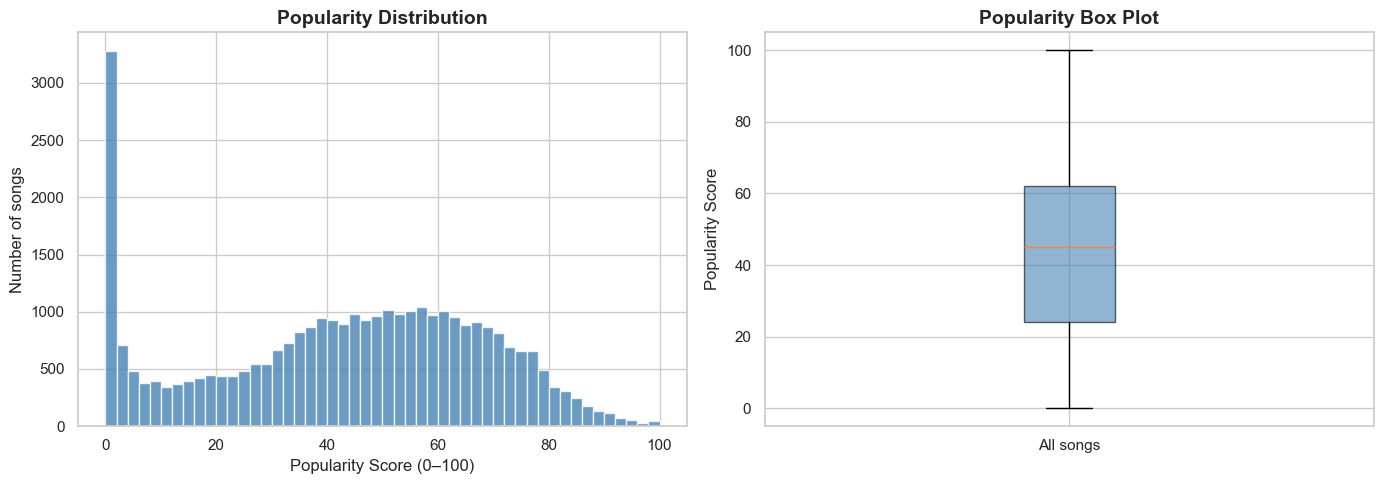

Mean popularity:   42.5
Median popularity: 45.0
Min popularity:    0
Max popularity:    100


In [6]:
# How is popularity distributed across songs?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 charts side by side

# Left chart: histogram
axes[0].hist(df['track_popularity'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Popularity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Number of songs')

# Right chart: box plot — shows median, spread, and outliers
axes[1].boxplot(df['track_popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Popularity Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Popularity Score')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['All songs'])

plt.tight_layout()  # Prevent charts from overlapping
plt.savefig('output_popularity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean popularity:   {df['track_popularity'].mean():.1f}")
print(f"Median popularity: {df['track_popularity'].median():.1f}")
print(f"Min popularity:    {df['track_popularity'].min()}")
print(f"Max popularity:    {df['track_popularity'].max()}")

---
## Cell 7 — Check for missing values
Real-world data is messy. Missing values (called `NaN` in pandas) can break models. We need to find and remove them.

In [7]:
# Count how many missing values exist in each column
missing = df.isnull().sum()

# Only show columns that actually have missing values
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('✅ No missing values found — the dataset is clean!')
else:
    print('⚠️  Missing values found:')
    print(missing_cols)

⚠️  Missing values found:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


---
## Cell 8 — Clean the data
Even without missing values, we should remove duplicates and drop songs with a popularity of 0 (these are usually unreleased or broken tracks — not truly underground).

In [8]:
original_count = len(df)

# Step 1: Remove exact duplicate rows
df = df.drop_duplicates()
print(f'After removing duplicates: {len(df):,} rows (removed {original_count - len(df):,})')

# Step 2: Remove duplicate track IDs (same song listed in multiple playlists)
df = df.drop_duplicates(subset='track_id')
print(f'After removing duplicate tracks: {len(df):,} rows')

# Step 3: Remove songs with popularity = 0 (these are often ghost/unreleased tracks)
# We want 'underground' to mean low but real popularity, not broken entries
df = df[df['track_popularity'] > 0]
print(f'After removing zero-popularity tracks: {len(df):,} rows')

# Step 4: Drop any rows that still have missing values (just in case)
df = df.dropna()
print(f'After dropping any remaining NaN rows: {len(df):,} rows')

print(f'\nTotal removed: {original_count - len(df):,} rows ({(original_count - len(df))/original_count*100:.1f}%)')

After removing duplicates: 32,833 rows (removed 0)
After removing duplicate tracks: 28,356 rows
After removing zero-popularity tracks: 25,736 rows
After dropping any remaining NaN rows: 25,736 rows

Total removed: 7,097 rows (21.6%)


---
## Cell 9 — Label songs: underground vs mainstream
This is the most important design decision in the whole project.

**Strategy:** We'll use the **25th percentile** as our cutoff.
- Bottom 25% of popularity → `underground`
- Top 25% of popularity → `mainstream`  
- Middle 50% → `mid` (we won't use these in modelling — the boundary is too blurry)

This is a deliberate, defensible choice you can explain to a recruiter: *"I used quartiles to create distinct categories rather than an arbitrary number, keeping the boundary crisp."*

In [9]:
# Calculate the 25th and 75th percentile of popularity
low_cutoff  = df['track_popularity'].quantile(0.25)  # bottom 25%
high_cutoff = df['track_popularity'].quantile(0.75)  # top 25%

print(f'Cutoffs → Underground: popularity ≤ {low_cutoff:.0f}')
print(f'          Mainstream:  popularity ≥ {high_cutoff:.0f}')
print(f'          Mid (ignored in modelling): {low_cutoff:.0f} to {high_cutoff:.0f}')

# Create a new column called 'label'
# We use pd.cut to assign categories based on ranges
def label_song(popularity):
    if popularity <= low_cutoff:
        return 'underground'
    elif popularity >= high_cutoff:
        return 'mainstream'
    else:
        return 'mid'

# .apply() runs our function on every row in the column
df['label'] = df['track_popularity'].apply(label_song)

# Count how many songs fall into each category
label_counts = df['label'].value_counts()
print('\nSong counts per label:')
print(label_counts)

Cutoffs → Underground: popularity ≤ 29
          Mainstream:  popularity ≥ 59
          Mid (ignored in modelling): 29 to 59

Song counts per label:
label
mid            12415
mainstream      6838
underground     6483
Name: count, dtype: int64


---
## Cell 10 — Visualise the labels
Always visualise your labels to confirm the split looks sensible.

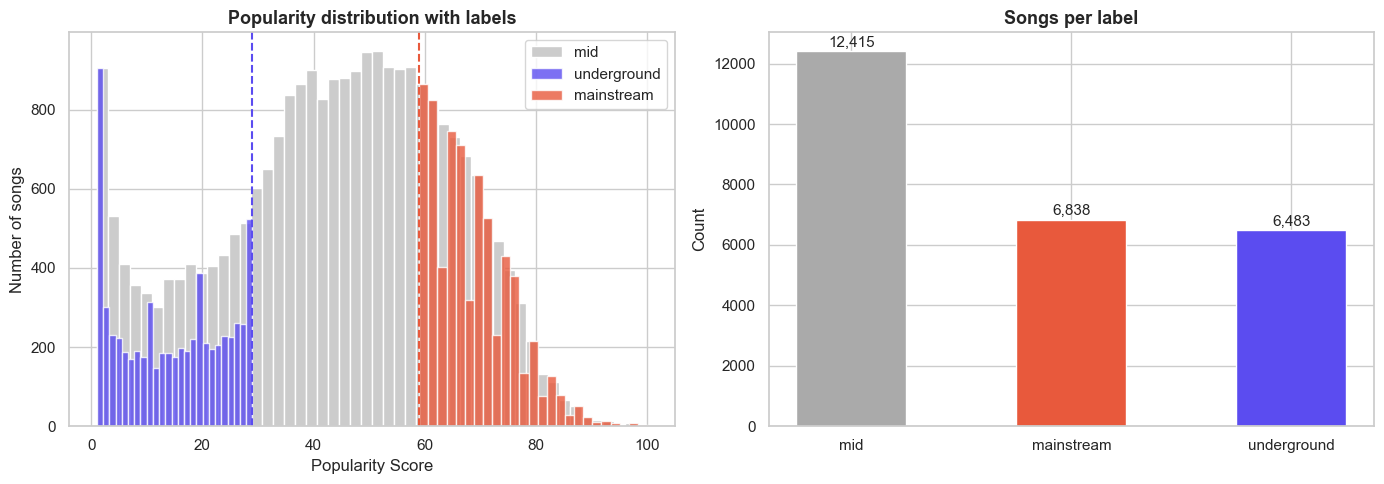

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with label zones shaded
axes[0].hist(df['track_popularity'], bins=50, color='#cccccc', edgecolor='white', label='mid')

underground_songs = df[df['label'] == 'underground']
mainstream_songs  = df[df['label'] == 'mainstream']

axes[0].hist(underground_songs['track_popularity'], bins=25, color='#5B4CF0', alpha=0.8, label='underground')
axes[0].hist(mainstream_songs['track_popularity'],  bins=25, color='#E8593C', alpha=0.8, label='mainstream')
axes[0].axvline(low_cutoff,  color='#5B4CF0', linestyle='--', linewidth=1.5)
axes[0].axvline(high_cutoff, color='#E8593C', linestyle='--', linewidth=1.5)
axes[0].set_title('Popularity distribution with labels', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Number of songs')
axes[0].legend()

# Right: bar chart of label counts
colors = {'underground': '#5B4CF0', 'mid': '#aaaaaa', 'mainstream': '#E8593C'}
bars = axes[1].bar(label_counts.index, label_counts.values,
                   color=[colors[l] for l in label_counts.index],
                   edgecolor='white', width=0.5)
axes[1].set_title('Songs per label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('output_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11 — Quick sanity check
Before saving, let's manually inspect 5 random songs from each label to make sure the results feel right. This is called a 'sanity check' — a quick gut-check before moving on.

In [11]:
# Columns to display in the sanity check
check_cols = ['track_name', 'track_artist', 'track_popularity', 'label']

print('=== 5 UNDERGROUND songs (should be obscure) ===')
print(df[df['label'] == 'underground'][check_cols].sample(5).to_string(index=False))

print('\n=== 5 MAINSTREAM songs (should be recognisable) ===')
print(df[df['label'] == 'mainstream'][check_cols].sample(5).to_string(index=False))

=== 5 UNDERGROUND songs (should be obscure) ===
        track_name   track_artist  track_popularity       label
          Champion   Fall Out Boy                 3 underground
         Get on Up Luis Rodriguez                 9 underground
Happy Relationship          Troop                 8 underground
           Inferno       Hechmann                26 underground
     Pardon My Ego          Logic                 6 underground

=== 5 MAINSTREAM songs (should be recognisable) ===
        track_name      track_artist  track_popularity      label
    That's My Girl     Fifth Harmony                70 mainstream
  Hail to the King Avenged Sevenfold                75 mainstream
            Mírame        Nio Garcia                66 mainstream
Little Do You Know     Alex & Sierra                79 mainstream
        ocean eyes     Billie Eilish                85 mainstream


---
## Cell 12 — Save clean data for Phase 2
We save two files:
- `df_clean.csv` — the full cleaned dataset (all 3 labels, all columns)
- `df_model.csv` — only underground + mainstream (for the clustering model)

Saving intermediate outputs is good practice. If Phase 2 breaks, you don't have to re-run Phase 1.

In [12]:
# Save the full cleaned dataset
df.to_csv('df_clean.csv', index=False)
print(f'✅ Saved df_clean.csv — {len(df):,} songs, all labels')

# Save just underground + mainstream for the model (drop 'mid' songs)
df_model = df[df['label'] != 'mid'].copy()
df_model.to_csv('df_model.csv', index=False)
print(f'✅ Saved df_model.csv — {len(df_model):,} songs (underground + mainstream only)')

print('\n📁 Your folder now contains:')
for f in ['spotify_songs.csv', 'df_clean.csv', 'df_model.csv',
          'output_popularity_distribution.png', 'output_label_distribution.png']:
    exists = '✅' if os.path.exists(f) else '❌ (not found)'
    print(f'   {exists} {f}')

✅ Saved df_clean.csv — 25,736 songs, all labels
✅ Saved df_model.csv — 13,321 songs (underground + mainstream only)

📁 Your folder now contains:
   ✅ spotify_songs.csv
   ✅ df_clean.csv
   ✅ df_model.csv
   ✅ output_popularity_distribution.png
   ✅ output_label_distribution.png


---
## ✅ Phase 1 Complete!

**What you built:**
- Loaded 30,000 real Spotify songs into Python
- Understood what each audio feature means
- Cleaned the data (removed duplicates, zero-popularity ghosts, nulls)
- Made a deliberate labelling decision (quartile-based underground vs mainstream)
- Visualised the distribution and confirmed the labels make sense
- Saved clean files ready for Phase 2

**What you learned:**
- `pd.read_csv()`, `df.head()`, `df.describe()`, `df.isnull().sum()`
- Cleaning: `drop_duplicates()`, `dropna()`, filtering with `df[condition]`
- Creating a new column from logic: `df['label'] = df['popularity'].apply(function)`
- Saving: `df.to_csv()`

---
**Next step → open `phase2_eda.ipynb` for the EDA and visualisations!**